# Batsman Workflow — Parallel (No LLM)

**Graph:** START → [calculate_strike_rate | calculate_balls_per_boundary | calculate_boundary_percent] → summary → END

**Key concept:** Parallel nodes must return partial state dicts, NOT the full state — otherwise LangGraph throws `InvalidUpdateError`.

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Optional

## Step 1 — Define State

In [2]:
class BatsmanState(TypedDict):
    # inputs
    runs: int
    balls: int
    fours: int
    sixes: int
    # computed by parallel nodes
    strike_rate: Optional[float]
    bpb: Optional[float]             # balls per boundary
    boundary_percent: Optional[float]
    summary: Optional[str]

## Step 2 — Define Nodes

> Parallel nodes return a **partial dict** (only the key they computed), not the full state.

In [3]:
def calculate_strike_rate(state: BatsmanState) -> dict:
    sr = (state['runs'] / state['balls']) * 100
    return {'strike_rate': round(sr, 2)}


def calculate_balls_per_boundary(state: BatsmanState) -> dict:
    bpb = state['balls'] / (state['fours'] + state['sixes'])
    return {'bpb': round(bpb, 2)}


def calculate_boundary_percent(state: BatsmanState) -> dict:
    boundary_runs = (state['fours'] * 4) + (state['sixes'] * 6)
    bp = (boundary_runs / state['runs']) * 100
    return {'boundary_percent': round(bp, 2)}


def summary(state: BatsmanState) -> dict:
    s = (
        f"Strike Rate      : {state['strike_rate']}\n"
        f"Balls/Boundary   : {state['bpb']}\n"
        f"Boundary Percent : {state['boundary_percent']}%"
    )
    return {'summary': s}

## Step 3 — Build Graph

In [4]:
graph = StateGraph(BatsmanState)

# Add nodes
graph.add_node('calculate_strike_rate', calculate_strike_rate)
graph.add_node('calculate_balls_per_boundary', calculate_balls_per_boundary)
graph.add_node('calculate_boundary_percent', calculate_boundary_percent)
graph.add_node('summary', summary)

# START fans out to 3 parallel nodes
graph.add_edge(START, 'calculate_strike_rate')
graph.add_edge(START, 'calculate_balls_per_boundary')
graph.add_edge(START, 'calculate_boundary_percent')

# All 3 converge into summary
graph.add_edge('calculate_strike_rate', 'summary')
graph.add_edge('calculate_balls_per_boundary', 'summary')
graph.add_edge('calculate_boundary_percent', 'summary')

graph.add_edge('summary', END)

workflow = graph.compile()
print('Graph compiled successfully!')

Graph compiled successfully!


## Step 4 — Visualise

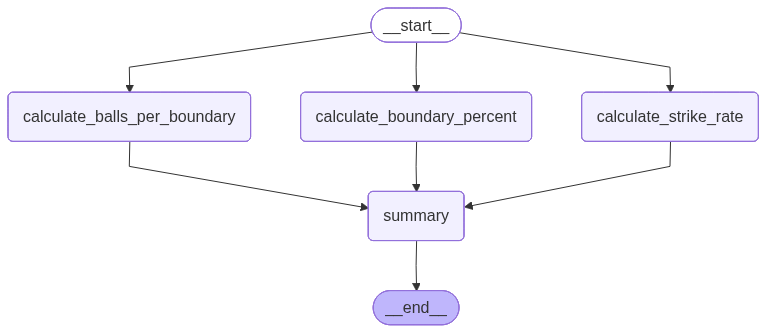

In [5]:
from IPython.display import Image, display
display(Image(workflow.get_graph().draw_mermaid_png()))

## Step 5 — Execute

In [6]:
initial_state = {
    'runs': 100,
    'balls': 50,
    'fours': 6,
    'sixes': 4,
    'strike_rate': None,
    'bpb': None,
    'boundary_percent': None,
    'summary': None
}

final_state = workflow.invoke(initial_state)
print(final_state['summary'])

Strike Rate      : 200.0
Balls/Boundary   : 5.0
Boundary Percent : 48.0%
